# E01 — Pretrained ResNet18 Training and Ablation Experiments

This is the core Notebook for Part E.

It includes three groups of experiments:

1. **main**: ImageNet pretrained weights + data augmentation + partial layer unfreezing;
2. **no_augmentation**: only data augmentation is removed, while all other settings remain unchanged;
3. **head_only**: the backbone is fully frozen, and only the final classification head is trained.

All three experiments must use the same train/validation split. Only one factor should be changed at a time to ensure a fair ablation study.

## Step 1: Locate the project root and import dependencies

In [21]:
import csv
import json
import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Subset
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm


def find_project_root(start_path):
    """Walk upwards from start_path until a folder containing the project layout is found."""
    current = Path(start_path).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data" / "processed").exists():
            return candidate
    # Fallback for Google Colab, where the repository is cloned to a fixed location
    colab_root = Path("/content/9517_assignment_MVP_Group")
    if colab_root.exists():
        return colab_root
    raise FileNotFoundError("Project repository was not found")


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.data import create_dataloader, create_dataset

print("Project root:", PROJECT_ROOT)
print("PyTorch:", torch.__version__)

Project root: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group
PyTorch: 2.13.0+cpu


In [22]:
DATA_RAW_ROOT = config.DATA_RAW_ROOT

TRAIN_IMAGE_DIR = DATA_RAW_ROOT / "train_mini"
TEST_IMAGE_DIR = DATA_RAW_ROOT / "val"

print("Data root:", DATA_RAW_ROOT)
print("Train folder:", TRAIN_IMAGE_DIR)
print("Test folder:", TEST_IMAGE_DIR)

print("Data root exists:", DATA_RAW_ROOT.exists())
print("Train folder exists:", TRAIN_IMAGE_DIR.exists())
print("Test folder exists:", TEST_IMAGE_DIR.exists())

Data root: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\data\raw
Train folder: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\data\raw\train_mini
Test folder: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\data\raw\val
Data root exists: True
Train folder exists: True
Test folder exists: True


In [23]:
train_df = pd.read_csv(config.TRAIN_CSV)
val_df = pd.read_csv(config.VAL_CSV)
test_df = pd.read_csv(config.TEST_CSV)

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

# Sanity check: make sure the relative paths in the CSV resolve to real image files
first_relative_path = train_df.iloc[0]["file_path"]
first_image_path = DATA_RAW_ROOT / first_relative_path

print("\nFirst relative path:")
print(first_relative_path)

print("\nComplete image path:")
print(first_image_path)

print("\nImage exists:")
print(first_image_path.exists())

Train rows: 20000
Validation rows: 5000
Test rows: 5000

First relative path:
train_mini/07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii/f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg

Complete image path:
C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\data\raw\train_mini\07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii\f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg

Image exists:
True


## Step 2: Fix the random seed and select the GPU

In [24]:
def set_random_seed(seed):
    """Seed every random source so that the three experiments stay comparable."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic mode: slower, but reproducible across runs
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    """Prefer CUDA, then Apple MPS, and fall back to CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


set_random_seed(config.RANDOM_SEED)
DEVICE = get_device()
print("Device:", DEVICE)

Device: cpu


## Step 3: Define the preprocessing for training and validation images

The training set uses random cropping, horizontal flipping, rotation and colour jitter.

The validation set uses no random augmentation, only a fixed resize, a center crop and ImageNet normalization.

In [25]:
def create_train_transform(use_augmentation=True):
    image_size = config.IMG_SIZE[0]

    # Ablation switch: without augmentation, training uses the same pipeline as evaluation
    if not use_augmentation:
        return create_eval_transform()

    return transforms.Compose(
        [
            transforms.RandomResizedCrop(image_size, scale=(0.75, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05,
            ),
            transforms.ToTensor(),
            transforms.Normalize(config.IMG_MEAN, config.IMG_STD),
        ]
    )


def create_eval_transform():
    image_size = config.IMG_SIZE[0]
    # Standard ImageNet evaluation ratio: resize to size / 0.875, then center crop
    resize_size = int(image_size / 0.875)

    return transforms.Compose(
        [
            transforms.Resize(resize_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(config.IMG_MEAN, config.IMG_STD),
        ]
    )

## Step 4: Create the ImageNet pretrained ResNet18

The last layer of the original ResNet18 is a 1000-class ImageNet classifier.

Here it is replaced by a 500-class classifier, and `train_mode` controls which layers take part in training:

- `head`: train only `fc`;
- `layer4`: train the last residual stage and `fc`;
- `all`: train the whole network.

In [26]:
def set_train_mode(model, train_mode):
    """Freeze everything first, then re-enable gradients for the selected layers."""
    valid_modes = {"head", "layer4", "all"}
    if train_mode not in valid_modes:
        raise ValueError(f"Unknown train mode: {train_mode}")

    for parameter in model.parameters():
        parameter.requires_grad = False

    if train_mode == "head":
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    if train_mode == "layer4":
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    if train_mode == "all":
        for parameter in model.parameters():
            parameter.requires_grad = True

    return model


def set_frozen_batchnorm_eval(model):
    """Keep frozen BatchNorm layers in eval mode so their running statistics are not updated."""
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            trainable = any(parameter.requires_grad for parameter in module.parameters())
            if not trainable:
                module.eval()


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def create_pretrained_resnet18(use_pretrained=True, train_mode="head"):
    weights = ResNet18_Weights.DEFAULT if use_pretrained else None
    model = resnet18(weights=weights)
    # Replace the 1000-class ImageNet head with a head for our own number of classes
    model.fc = nn.Linear(model.fc.in_features, config.NUM_CLASSES)
    return set_train_mode(model, train_mode)

## Step 5: Run a model architecture smoke test first

In [27]:
smoke_model = create_pretrained_resnet18(use_pretrained=False, train_mode="head")
smoke_input = torch.randn(2, 3, config.IMG_SIZE[0], config.IMG_SIZE[1])
smoke_output = smoke_model(smoke_input)

print("Output shape:", tuple(smoke_output.shape))
print("Expected shape:", (2, config.NUM_CLASSES))
print("Trainable parameters (head):", f"{count_trainable_parameters(smoke_model):,}")

assert smoke_output.shape == (2, config.NUM_CLASSES)

Output shape: (2, 500)
Expected shape: (2, 500)
Trainable parameters (head): 256,500


## Step 6: Define the training and validation metrics

In [28]:
def calculate_topk(logits, labels, topk=(1, 5)):
    """Count how many samples in the batch have the true label inside the top-k predictions."""
    max_k = min(max(topk), logits.shape[1])
    predictions = logits.topk(max_k, dim=1).indices
    correct = predictions.eq(labels.view(-1, 1))

    results = {}
    for k in topk:
        current_k = min(k, logits.shape[1])
        results[k] = correct[:, :current_k].any(dim=1).sum().item()
    return results


def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device, use_amp):
    model.train()
    # Frozen BatchNorm layers must stay in eval mode even after model.train()
    set_frozen_batchnorm_eval(model)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress = tqdm(dataloader, leave=False)
    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass (only active on CUDA)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Weight the batch loss by batch size so the epoch average is correct
        batch_size = labels.shape[0]
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return {
        "loss": total_loss / total_samples,
        "top1": total_correct / total_samples,
    }


def validate_one_epoch(model, dataloader, criterion, device, use_amp):
    model.eval()

    total_loss = 0.0
    total_top1 = 0
    total_top5 = 0
    total_samples = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

            topk = calculate_topk(logits, labels)
            predictions = logits.argmax(dim=1)
            batch_size = labels.shape[0]

            total_loss += loss.item() * batch_size
            total_top1 += topk[1]
            total_top5 += topk[5]
            total_samples += batch_size
            # Collect all predictions so macro-F1 can be computed over the whole set
            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return {
        "loss": total_loss / total_samples,
        "top1": total_top1 / total_samples,
        "top5": total_top5 / total_samples,
        "macro_f1": macro_f1,
    }

## Step 7: Define checkpointing, history logging and the full training loop

In [29]:
def save_history(history, output_path):
    """Write the per-epoch metric rows to a CSV file."""
    if not history:
        return

    with Path(output_path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        writer.writeheader()
        writer.writerows(history)


def save_checkpoint(
    checkpoint_path,
    model,
    optimizer,
    scheduler,
    stage_index,
    stage_epoch,
    global_epoch,
    best_val_top1,
    history,
    run_config,
):
    """Save everything needed to resume training exactly where it stopped."""
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "stage_index": stage_index,
        "stage_epoch": stage_epoch,
        "global_epoch": global_epoch,
        "best_val_top1": best_val_top1,
        "history": history,
        "run_config": run_config,
    }
    torch.save(checkpoint, checkpoint_path)


def fit_transfer_model(
    model,
    train_loader,
    val_loader,
    stages,
    output_dir,
    run_config,
    device,
    resume=False,
    label_smoothing=0.1,
    weight_decay=1e-4,
):
    """Run staged transfer learning: each stage unfreezes more layers with a smaller learning rate."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = []
    best_val_top1 = -1.0
    global_epoch = 0
    resume_stage_index = 0
    resume_stage_epoch = 0
    resume_optimizer_state = None
    resume_scheduler_state = None

    last_checkpoint_path = output_dir / "last_checkpoint.pth"
    best_checkpoint_path = output_dir / "best_checkpoint.pth"

    # Restore the previous run if one exists (useful when Colab disconnects)
    if resume and last_checkpoint_path.exists():
        checkpoint = torch.load(last_checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint["model_state_dict"])
        history = checkpoint.get("history", [])
        best_val_top1 = checkpoint.get("best_val_top1", -1.0)
        global_epoch = checkpoint.get("global_epoch", 0)
        resume_stage_index = checkpoint.get("stage_index", 0)
        # Continue from the epoch after the one that was last completed
        resume_stage_epoch = checkpoint.get("stage_epoch", 0) + 1
        resume_optimizer_state = checkpoint.get("optimizer_state_dict")
        resume_scheduler_state = checkpoint.get("scheduler_state_dict")
        print(f"Resume from stage {resume_stage_index + 1}, epoch {resume_stage_epoch + 1}")

    # Store the exact configuration next to the results for reproducibility
    with (output_dir / "run_config.json").open("w", encoding="utf-8") as f:
        json.dump(run_config, f, indent=2)

    for stage_index, stage in enumerate(stages):
        # Skip the stages that were already finished before the interruption
        if stage_index < resume_stage_index:
            continue

        set_train_mode(model, stage["train_mode"])
        trainable_parameters = [
            parameter for parameter in model.parameters() if parameter.requires_grad
        ]

        # A fresh optimizer and scheduler are created for every stage
        optimizer = AdamW(
            trainable_parameters,
            lr=stage["learning_rate"],
            weight_decay=weight_decay,
        )
        scheduler = CosineAnnealingLR(optimizer, T_max=max(stage["epochs"], 1))

        start_epoch = 0
        if stage_index == resume_stage_index and resume_stage_epoch > 0:
            start_epoch = resume_stage_epoch
            if resume_optimizer_state is not None:
                optimizer.load_state_dict(resume_optimizer_state)
            if resume_scheduler_state is not None:
                scheduler.load_state_dict(resume_scheduler_state)

        print()
        print(f"Stage {stage_index + 1}: {stage['name']}")
        print("Train mode:", stage["train_mode"])
        print("Trainable parameters:", f"{count_trainable_parameters(model):,}")

        for stage_epoch in range(start_epoch, stage["epochs"]):
            epoch_start = time.perf_counter()

            train_metrics = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                scaler,
                device,
                use_amp,
            )
            val_metrics = validate_one_epoch(
                model,
                val_loader,
                criterion,
                device,
                use_amp,
            )

            # Record the learning rate that was actually used before the scheduler steps
            current_learning_rate = optimizer.param_groups[0]["lr"]
            scheduler.step()
            global_epoch += 1
            epoch_seconds = time.perf_counter() - epoch_start

            row = {
                "global_epoch": global_epoch,
                "stage": stage["name"],
                "stage_epoch": stage_epoch + 1,
                "learning_rate": current_learning_rate,
                "train_loss": train_metrics["loss"],
                "train_top1": train_metrics["top1"],
                "val_loss": val_metrics["loss"],
                "val_top1": val_metrics["top1"],
                "val_top5": val_metrics["top5"],
                "val_macro_f1": val_metrics["macro_f1"],
                "epoch_seconds": epoch_seconds,
            }
            history.append(row)
            # Write the history after every epoch so nothing is lost on a crash
            save_history(history, output_dir / "history.csv")

            # Keep a separate copy of the best model by validation Top-1
            if val_metrics["top1"] > best_val_top1:
                best_val_top1 = val_metrics["top1"]
                save_checkpoint(
                    best_checkpoint_path,
                    model,
                    optimizer,
                    scheduler,
                    stage_index,
                    stage_epoch,
                    global_epoch,
                    best_val_top1,
                    history,
                    run_config,
                )

            save_checkpoint(
                last_checkpoint_path,
                model,
                optimizer,
                scheduler,
                stage_index,
                stage_epoch,
                global_epoch,
                best_val_top1,
                history,
                run_config,
            )

            print(
                f"Epoch {global_epoch:02d} | "
                f"train loss {train_metrics['loss']:.4f} | "
                f"train top1 {train_metrics['top1']:.4f} | "
                f"val top1 {val_metrics['top1']:.4f} | "
                f"val top5 {val_metrics['top5']:.4f} | "
                f"val macro F1 {val_metrics['macro_f1']:.4f} | "
                f"{epoch_seconds:.1f}s"
            )

        # The resume offsets only apply to the first stage that is picked up again
        resume_stage_epoch = 0
        resume_optimizer_state = None
        resume_scheduler_state = None

    return history

## Step 8: Define the three groups of experiments

`main` and `no_augmentation` use exactly the same training stages; only the data augmentation changes.

`head_only` also keeps a total of 12 epochs, so that a different number of training epochs does not make the comparison unfair.

In [30]:
EXPERIMENTS = {
    # Full recipe: augmentation on, progressively unfreezing head -> layer4 -> all
    "main": {
        "use_augmentation": True,
        "stages": [
            {"name": "head", "train_mode": "head", "epochs": 2, "learning_rate": 1e-3},
            {"name": "layer4", "train_mode": "layer4", "epochs": 6, "learning_rate": 3e-4},
            {"name": "all", "train_mode": "all", "epochs": 4, "learning_rate": 1e-4},
        ],
    },
    # Ablation 1: identical to main except that augmentation is switched off
    "no_augmentation": {
        "use_augmentation": False,
        "stages": [
            {"name": "head", "train_mode": "head", "epochs": 2, "learning_rate": 1e-3},
            {"name": "layer4", "train_mode": "layer4", "epochs": 6, "learning_rate": 3e-4},
            {"name": "all", "train_mode": "all", "epochs": 4, "learning_rate": 1e-4},
        ],
    },
    # Ablation 2: backbone completely frozen, same 12-epoch budget
    "head_only": {
        "use_augmentation": True,
        "stages": [
            {"name": "head", "train_mode": "head", "epochs": 12, "learning_rate": 1e-3},
        ],
    },
}

## Step 9: Set the output location and create the DataLoaders

In [31]:
# Save to Google Drive when running in Colab, otherwise to the local output folder
IS_COLAB = Path("/content/drive/MyDrive").exists()

if IS_COLAB:
    OUTPUT_ROOT = Path("/content/drive/MyDrive/COMP9517/outputs/pretrained")
else:
    OUTPUT_ROOT = config.OUTPUT_ROOT / "pretrained"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 8
NUM_WORKERS = 0


def build_dataloaders(experiment_name, limit_train=None, limit_val=None):
    """Build the train/validation loaders; limit_* is only used for quick smoke tests."""
    experiment = EXPERIMENTS[experiment_name]

    train_dataset = create_dataset(
        "train",
        image_root=config.DATA_RAW_ROOT,
        transform=create_train_transform(experiment["use_augmentation"]),
    )
    # Validation always uses the deterministic transform, in every experiment
    val_dataset = create_dataset(
        "val",
        image_root=config.DATA_RAW_ROOT,
        transform=create_eval_transform(),
    )

    if limit_train is not None:
        train_dataset = Subset(train_dataset, range(min(limit_train, len(train_dataset))))
    if limit_val is not None:
        val_dataset = Subset(val_dataset, range(min(limit_val, len(val_dataset))))

    train_loader = create_dataloader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    )
    val_loader = create_dataloader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    )

    return train_loader, val_loader


print("Output root:", OUTPUT_ROOT)

Output root: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained


In [32]:
# Quick check that a single sample loads and has the expected shape
test_train_dataset = create_dataset(
    "train",
    image_root=DATA_RAW_ROOT,
    transform=create_eval_transform(),
)

print("Dataset size:", len(test_train_dataset))

image, label = test_train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Dataset size: 20000
Image shape: torch.Size([3, 224, 224])
Label: 364


In [33]:
# Quick check that batching works and that the label range is valid
test_train_loader = create_dataloader(
    test_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

images, labels = next(iter(test_train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Label minimum:", labels.min().item())
print("Label maximum:", labels.max().item())

Images: torch.Size([8, 3, 224, 224])
Labels: torch.Size([8])
Label minimum: 45
Label maximum: 450


## Step 10: Run a very small training test first

This cell only confirms that the whole training pipeline runs.

It is not an official experimental result and must not be written into the final report.

In [34]:
RUN_SMALL_TEST = True

if RUN_SMALL_TEST:
    # Tiny subsets and a single epoch: this is a pipeline check, not a real result
    small_train_loader, small_val_loader = build_dataloaders(
        "main",
        limit_train=64,
        limit_val=32,
    )

    small_model = create_pretrained_resnet18(
        use_pretrained=True,
        train_mode="head",
    )

    small_stages = [
        {
            "name": "small_test",
            "train_mode": "head",
            "epochs": 1,
            "learning_rate": 1e-3,
        }
    ]

    small_config = {
        "experiment": "small_test",
        "random_seed": config.RANDOM_SEED,
        "num_classes": config.NUM_CLASSES,
        "stages": small_stages,
    }

    small_history = fit_transfer_model(
        small_model,
        small_train_loader,
        small_val_loader,
        small_stages,
        OUTPUT_ROOT / "small_test",
        small_config,
        DEVICE,
        resume=False,
    )


Stage 1: small_test
Train mode: head
Trainable parameters: 256,500


Epoch 01 | train loss 4.1168 | train top1 0.2969 | val top1 0.1250 | val top5 0.6250 | val macro F1 0.0774 | 1.7s


## Step 11: Wrap the official experiment runner

If Colab disconnects, set `resume=True` and run the same experiment again to continue.

In [35]:
def run_experiment(experiment_name, resume=True):
    if experiment_name not in EXPERIMENTS:
        raise ValueError(f"Unknown experiment: {experiment_name}")

    # Reseed before every experiment so all three start from the same state
    set_random_seed(config.RANDOM_SEED)
    experiment = EXPERIMENTS[experiment_name]
    output_dir = OUTPUT_ROOT / experiment_name
    last_checkpoint = output_dir / "last_checkpoint.pth"

    train_loader, val_loader = build_dataloaders(experiment_name)
    # When resuming, downloading the ImageNet weights is pointless: the checkpoint overwrites them
    use_pretrained = not (resume and last_checkpoint.exists())
    model = create_pretrained_resnet18(
        use_pretrained=use_pretrained,
        train_mode="head",
    )

    run_config = {
        "experiment": experiment_name,
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "random_seed": config.RANDOM_SEED,
        "num_classes": config.NUM_CLASSES,
        "image_size": list(config.IMG_SIZE),
        "use_augmentation": experiment["use_augmentation"],
        "stages": experiment["stages"],
        "device": str(DEVICE),
        "torch_version": torch.__version__,
    }

    print(json.dumps(run_config, indent=2))

    return fit_transfer_model(
        model,
        train_loader,
        val_loader,
        experiment["stages"],
        output_dir,
        run_config,
        DEVICE,
        resume=resume,
    )

## Step 12: Officially train the main model

Set `RUN_MAIN = True` for the first run.

Once finished you will have:

```text
main/
├── best_checkpoint.pth
├── last_checkpoint.pth
├── history.csv
└── run_config.json
```

In [36]:
RUN_MAIN = False

if RUN_MAIN:
    main_history = run_experiment("main", resume=True)

## Step 13: Officially train the no-augmentation ablation experiment

In [37]:
RUN_NO_AUGMENTATION = False

if RUN_NO_AUGMENTATION:
    no_augmentation_history = run_experiment("no_augmentation", resume=True)

## Step 14: Officially train the head-only ablation experiment

In [38]:
RUN_HEAD_ONLY = False

if RUN_HEAD_ONLY:
    head_only_history = run_experiment("head_only", resume=True)

## Step 15: Inspect the training curves

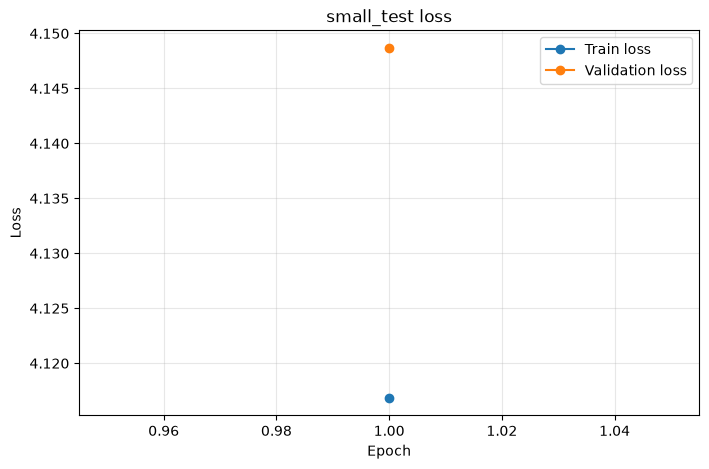

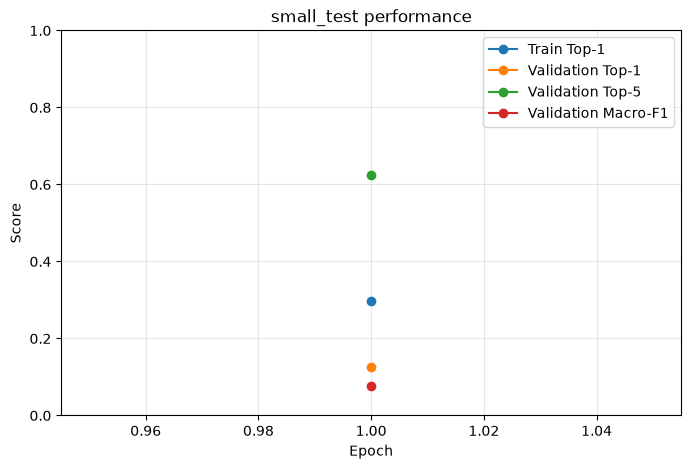

In [39]:
def plot_history(experiment_name):
    """Plot the loss curves and the metric curves for one experiment."""
    history_path = OUTPUT_ROOT / experiment_name / "history.csv"
    if not history_path.exists():
        print("History not found:", history_path)
        return

    history_df = pd.read_csv(history_path)

    # Figure 1: training loss versus validation loss (used to spot overfitting)
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["global_epoch"], history_df["train_loss"], marker="o", label="Train loss")
    plt.plot(history_df["global_epoch"], history_df["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name} loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Figure 2: Top-1, Top-5 and macro-F1
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["global_epoch"], history_df["train_top1"], marker="o", label="Train Top-1")
    plt.plot(history_df["global_epoch"], history_df["val_top1"], marker="o", label="Validation Top-1")
    plt.plot(history_df["global_epoch"], history_df["val_top5"], marker="o", label="Validation Top-5")
    plt.plot(history_df["global_epoch"], history_df["val_macro_f1"], marker="o", label="Validation Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{experiment_name} performance")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_history("small_test")

## E01 completion criteria

For each of the three experiments you must keep:

- `best_checkpoint.pth`;
- `last_checkpoint.pth`;
- `history.csv`;
- `run_config.json`;
- the training/validation loss curves;
- the Top-1, Top-5 and Macro-F1 curves.

Checkpoints are large and should not be committed to GitHub; the Notebook and the final lightweight figures can be committed.